F1-score RF: 0.9472761401557286
F1-score XGB: 0.9601928068223952
F1-score Stacking: 0.957370226177234


c:\Users\zychl\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\zychl\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\zychl\anaconda3\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\zychl\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1640, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values 

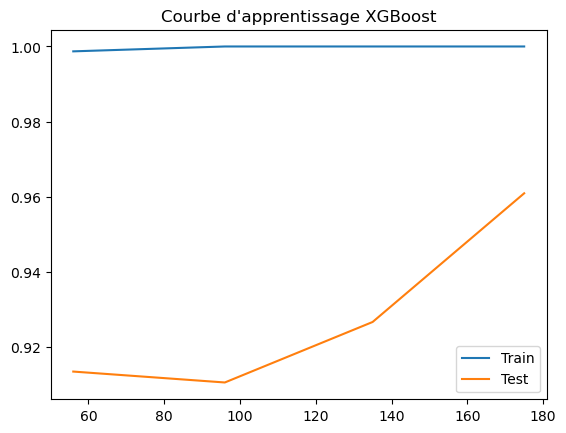

In [2]:
# 03_modelisation.ipynb
!pip install xgboost
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import seaborn as sns


url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
try:
    Dataset = pd.read_csv(url)
except Exception as e:
    print(f"Erreur de chargement des données : {e}")

# Modèles de base
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
xgb = XGBClassifier(random_state=42, objective='binary:logistic')

# Validation croisée 10 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Définition des variables explicatives et de la cible
if 'name' in Dataset.columns and 'status' in Dataset.columns:
    X_selected = Dataset.drop(columns=['name', 'status'])
    y_res = Dataset['status']
else:
    print("Colonnes 'name' et 'status' non trouvées dans le dataset.")
rf_scores = cross_val_score(rf, X_selected, y_res, cv=cv, scoring='f1', error_score='raise')
xgb_scores = cross_val_score(xgb, X_selected, y_res, cv=cv, scoring='f1', error_score='raise')
print("F1-score RF:", np.mean(rf_scores))
print("F1-score XGB:", np.mean(xgb_scores))

# Stacking
estimators = [('rf', rf), ('xgb', xgb)]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_scores = cross_val_score(stack, X_selected, y_res, cv=cv, scoring='f1')
print("F1-score Stacking:", np.mean(stack_scores))

# Courbes d'apprentissage
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(xgb, X_selected, y_res, cv=cv, scoring='f1')
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
plt.legend()
plt.title('Courbe d\'apprentissage XGBoost')
plt.show()